<div style="text-align: right">   </div>


Introduction to Deep Learning (2024) &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;&nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;&nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;&nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;&nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;| &nbsp;
-------|-------------------
**Assignment 2 - Sequence processing using RNNs** | <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/b/b0/UniversiteitLeidenLogo.svg/1280px-UniversiteitLeidenLogo.svg.png" width="300">



# Introduction


The goal of this assignment is to learn how to use encoder-decoder recurrent neural networks (RNNs). Specifically we will be dealing with a sequence to sequence problem and try to build recurrent models that can learn the principles behind simple arithmetic operations (**integer addition, subtraction and multiplication.**).

<img src="https://i.ibb.co/5Ky5pbk/Screenshot-2023-11-10-at-07-51-21.png" alt="Screenshot-2023-11-10-at-07-51-21" border="0" width="500"></a>

In this assignment you will be working with three different kinds of models, based on input/output data modalities:
1. **Text-to-text**: given a text query containing two integers and an operand between them (+ or -) the model's output should be a sequence of integers that match the actual arithmetic result of this operation
2. **Image-to-text**: same as above, except the query is specified as a sequence of images containing individual digits and an operand.
3. **Text-to-image**: the query is specified in text format as in the text-to-text model, however the model's output should be a sequence of images corresponding to the correct result.


### Description**
Let us suppose that we want to develop a neural network that learns how to add or subtract
two integers that are at most two digits long. For example, given input strings of 5 characters: ‘81+24’ or
’41-89’ that consist of 2 two-digit long integers and an operand between them, the network should return a
sequence of 3 characters: ‘105 ’ or ’-48 ’ that represent the result of their respective queries. Additionally,
we want to build a model that generalizes well - if the network can extract the underlying principles behind
the ’+’ and ’-’ operands and associated operations, it should not need too many training examples to generate
valid answers to unseen queries. To represent such queries we need 13 unique characters: 10 for digits (0-9),
2 for the ’+’ and ’-’ operands and one for whitespaces ’ ’ used as padding.
The example above describes a text-to-text sequence mapping scenario. However, we can also use different
modalities of data to represent our queries or answers. For that purpose, the MNIST handwritten digit
dataset is going to be used again, however in a slightly different format. The functions below will be used to create our datasets.

---

*To work on this notebook you should create a copy of it.*


# Function definitions for creating the datasets

First we need to create our datasets that are going to be used for training our models.

In order to create image queries of simple arithmetic operations such as '15+13' or '42-10' we need to create images of '+' and '-' signs using ***open-cv*** library. We will use these operand signs together with the MNIST dataset to represent the digits.

In [113]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import numpy as np
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Dense, RNN, LSTM, Flatten, TimeDistributed, LSTMCell, BatchNormalization, Dropout
from tensorflow.keras.layers import RepeatVector, Conv2D, Conv3D, SimpleRNN, GRU, Reshape, ConvLSTM2D, Conv2DTranspose, Flatten, Input, MaxPooling2D, MaxPooling3D
import keras

import matplotlib.pyplot as plt

In [2]:
seed = 8032
keras.utils.set_random_seed(seed)

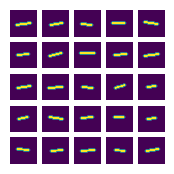

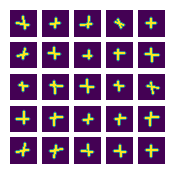

In [3]:
from scipy.ndimage import rotate


# Create plus/minus operand signs
def generate_images(number_of_images=50, sign='-'):
    blank_images = np.zeros([number_of_images, 28, 28])  # Dimensionality matches the size of MNIST images (28x28)
    x = np.random.randint(12, 16, (number_of_images, 2)) # Randomized x coordinates
    y1 = np.random.randint(6, 10, number_of_images)       # Randomized y coordinates
    y2 = np.random.randint(18, 22, number_of_images)     # -||-

    for i in range(number_of_images): # Generate n different images
        cv2.line(blank_images[i], (y1[i], x[i,0]), (y2[i], x[i, 1]), (255,0,0), 2, cv2.LINE_AA)     # Draw lines with randomized coordinates
        if sign == '+':
            cv2.line(blank_images[i], (x[i,0], y1[i]), (x[i, 1], y2[i]), (255,0,0), 2, cv2.LINE_AA) # Draw lines with randomized coordinates
        if sign == '*':
            cv2.line(blank_images[i], (x[i,0], y1[i]), (x[i, 1], y2[i]), (255,0,0), 2, cv2.LINE_AA)
            # Rotate 45 degrees
            blank_images[i] = rotate(blank_images[i], -50, reshape=False)
            cv2.line(blank_images[i], (x[i,0], y1[i]), (x[i, 1], y2[i]), (255,0,0), 2, cv2.LINE_AA)
            blank_images[i] = rotate(blank_images[i], -50, reshape=False)
            cv2.line(blank_images[i], (x[i,0], y1[i]), (x[i, 1], y2[i]), (255,0,0), 2, cv2.LINE_AA)

    return blank_images

def show_generated(images, n=5):
    plt.figure(figsize=(2, 2))
    for i in range(n**2):
        plt.subplot(n, n, i+1)
        plt.axis('off')
        plt.imshow(images[i])
    plt.show()

show_generated(generate_images())
show_generated(generate_images(sign='+'))

In [4]:
def create_data(highest_integer, num_addends=2, operands=['+', '-']):
    """
    Creates the following data for all pairs of integers up to [1:highest integer][+/-][1:highest_integer]:

    @return:
    X_text: '51+21' -> text query of an arithmetic operation (5)
    X_img : Stack of MNIST images corresponding to the query (5 x 28 x 28) -> sequence of 5 images of size 28x28
    y_text: '72' -> answer of the arithmetic text query
    y_img :  Stack of MNIST images corresponding to the answer (3 x 28 x 28)

    Images for digits are picked randomly from the whole MNIST dataset.
    """

    num_indices = [np.where(MNIST_labels==x) for x in range(10)]
    num_data = [MNIST_data[inds] for inds in num_indices]
    image_mapping = dict(zip(unique_characters[:10], num_data))
    image_mapping['-'] = generate_images()
    image_mapping['+'] = generate_images(sign='+')
    image_mapping['*'] = generate_images(sign='*')
    image_mapping[' '] = np.zeros([1, 28, 28])

    X_text, X_img, y_text, y_img = [], [], [], []

    for i in range(highest_integer + 1):      # First addend
        for j in range(highest_integer + 1):  # Second addend
            for sign in operands: # Create all possible combinations of operands
                query_string = to_padded_chars(str(i) + sign + str(j), max_len=max_query_length, pad_right=True)
                query_image = []
                for n, char in enumerate(query_string):
                    image_set = image_mapping[char]
                    index = np.random.randint(0, len(image_set), 1)
                    query_image.append(image_set[index].squeeze())

                result = eval(query_string)
                result_string = to_padded_chars(result, max_len=max_answer_length, pad_right=True)
                result_image = []
                for n, char in enumerate(result_string):
                    image_set = image_mapping[char]
                    index = np.random.randint(0, len(image_set), 1)
                    result_image.append(image_set[index].squeeze())

                X_text.append(query_string)
                X_img.append(np.stack(query_image))
                y_text.append(result_string)
                y_img.append(np.stack(result_image))

    return np.stack(X_text), np.stack(X_img)/255., np.stack(y_text), np.stack(y_img)/255.

def to_padded_chars(integer, max_len=3, pad_right=False):
    """
    Returns a string of len()=max_len, containing the integer padded with ' ' on either right or left side
    """
    length = len(str(integer))
    padding = (max_len - length) * ' '
    if pad_right:
        return str(integer) + padding
    else:
        return padding + str(integer)


# Creating our data

The dataset consists of 20000 samples that (additions and subtractions between all 2-digit integers) and they have two kinds of inputs and label modalities:

  **X_text**: strings containing queries of length 5: ['  1+1  ', '11-18', ...]

  **X_image**: a stack of images representing a single query, dimensions: [5, 28, 28]

  **y_text**: strings containing answers of length 3: ['  2', '156']

  **y_image**: a stack of images that represents the answer to a query, dimensions: [3, 28, 28]

(20000,) (20000, 5, 28, 28) (20000,) (20000, 3, 28, 28)
Query #8567

X_text: "42-83" = y_text: "-41"


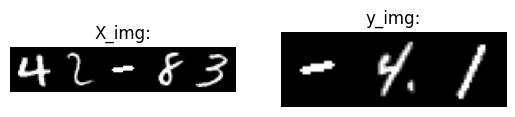

Query #9362

X_text: "46+81" = y_text: "127"


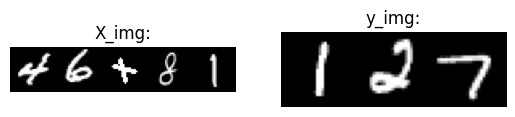

Query #9304

X_text: "46+52" = y_text: "98 "


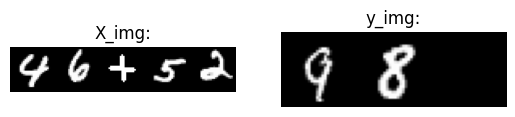

Query #478

X_text: "2+39 " = y_text: "41 "


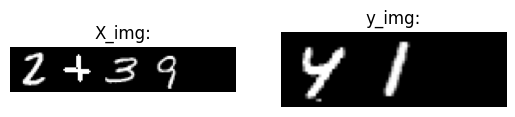

Query #1030

X_text: "5+15 " = y_text: "20 "


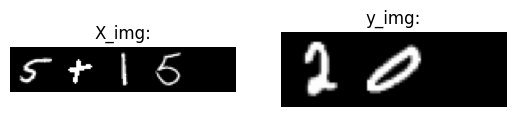

Query #8160

X_text: "40+80" = y_text: "120"


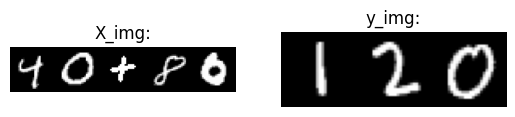

Query #4525

X_text: "22-62" = y_text: "-40"


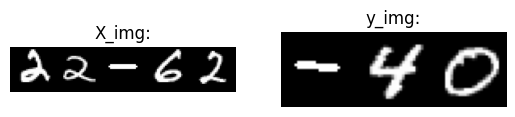

Query #9096

X_text: "45+48" = y_text: "93 "


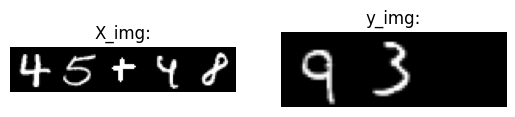

Query #2685

X_text: "13-42" = y_text: "-29"


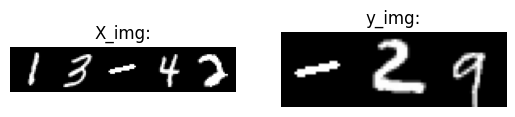

Query #6393

X_text: "31-96" = y_text: "-65"


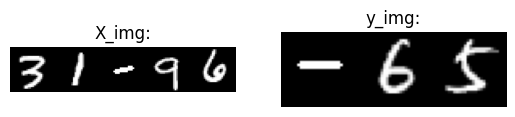

In [5]:
# Illustrate the generated query/answer pairs

unique_characters = '0123456789+- '       # All unique characters that are used in the queries (13 in total: digits 0-9, 2 operands [+, -], and a space character ' '.)
highest_integer = 99                      # Highest value of integers contained in the queries

max_int_length = len(str(highest_integer))# Maximum number of characters in an integer
max_query_length = max_int_length * 2 + 1 # Maximum length of the query string (consists of two integers and an operand [e.g. '22+10'])
max_answer_length = 3    # Maximum length of the answer string (the longest resulting query string is ' 1-99'='-98')

# Create the data (might take around a minute)
(MNIST_data, MNIST_labels), _ = tf.keras.datasets.mnist.load_data()
X_text, X_img, y_text, y_img = create_data(highest_integer)
print(X_text.shape, X_img.shape, y_text.shape, y_img.shape)


## Display the samples that were created
def display_sample(n):
    labels = ['X_img:', 'y_img:']
    for i, data in enumerate([X_img, y_img]):
        plt.subplot(1,2,i+1)
        # plt.set_figheight(15)
        plt.axis('off')
        plt.title(labels[i])
        plt.imshow(np.hstack(data[n]), cmap='gray')
    print('='*50, f'\nQuery #{n}\n\nX_text: "{X_text[n]}" = y_text: "{y_text[n]}"')
    plt.show()

for _ in range(10):
    display_sample(np.random.randint(0, 10000, 1)[0])

## Helper functions

The functions below will help with input/output of the data.

In [109]:
# One-hot encoding/decoding the text queries/answers so that they can be processed using RNNs
# You should use these functions to convert your strings and read out the output of your networks

def encode_labels(labels, max_len=3):
  n = len(labels)
  length = len(labels[0])
  char_map = dict(zip(unique_characters, range(len(unique_characters))))
  one_hot = np.zeros([n, length, len(unique_characters)])
  for i, label in enumerate(labels):
      m = np.zeros([length, len(unique_characters)])
      for j, char in enumerate(label):
          m[j, char_map[char]] = 1
      one_hot[i] = m

  return one_hot


def decode_labels(labels):
    pred = np.argmax(labels, axis=1)
    predicted = ''.join([unique_characters[i] for i in pred])

    return predicted

X_text_onehot = encode_labels(X_text)
y_text_onehot = encode_labels(y_text)

print(X_text_onehot.shape, y_text_onehot.shape)

(20000, 5, 13) (20000, 3, 13)


In [75]:
def plotter_1(X, y_true, text_preds):
    error_counter = 0
    error_in = np.zeros(13, dtype=np.int16)
    
    for i in range(text_preds.shape[0]):
        if decode_labels(y_true[i]) != decode_labels(text_preds[i]):
            error_in += np.where(np.sum(X[i], axis=0)>0, 1, 0)
            error_counter += 1

    x = np.arange(10)
    width = 0.25
    chars = [str(i) for i in range(10)]
    plt.figure(figsize=(8,4))
    
    plt.subplot(1,2,1)
    plt.bar(x, error_in[:10])
    plt.xticks(x, chars)
    plt.title("Error Count per Number in Query")
    
    plt.subplot(1,2,2)
    plt.pie(error_in[10:12], labels=[unique_characters[i] for i in range(10, 12)], autopct='%1.1f%%', pctdistance=1.25, labeldistance=.6)
    plt.title("Percentage of Mistakes by Operation Sign")
    
    plt.show()
    return error_counter, error_in

In [76]:
def plotter_2(y_true, text_preds):
    error_counter = 0
    error_out = np.zeros(13, dtype=np.int16)
    pos_err = 0
    
    for i in range(text_preds.shape[0]):
        if decode_labels(y_true[i]) != decode_labels(text_preds[i]):
            error_out += np.where(np.sum(y_true[i], axis=0)>0, 1, 0)
            error_counter += 1
            if np.sum(y_true[i], axis=0)[11] == 0:
                pos_err += 1
            
    x = np.arange(10)
    width = 0.25
    chars = [str(i) for i in range(10)]
    plt.figure(figsize=(8,4))
    
    plt.subplot(1,2,1)
    plt.bar(x, error_out[:10])
    plt.xticks(x, chars)
    plt.title("Error Count per Number in True Output")

    plt.subplot(1,2,2)
    plt.pie([pos_err,error_out[11]], labels=["+","-"], autopct='%1.1f%%', pctdistance=1.25, labeldistance=.6)
    plt.title("Percentage of mistakes by Output sign")
    plt.show()
    return error_counter, error_out

In [134]:
def mean_absolute_error(y_true,y_pred):
    err = 0

    for i in range(y_true.shape[0]):
        y = decode_labels(y_true[i])
        yhat = decode_labels(y_pred[i])
        try:
            err += abs(int(y)-int(yhat))
        except ValueError:
            err += int(y)
            
    
    return err/y_true.shape[0]

# Models

---
---

## I. Text-to-text RNN model

The following code showcases how Recurrent Neural Networks (RNNs) are built using Keras. Several new layers are going to be used:

1. LSTM
2. TimeDistributed
3. RepeatVector

The code cell below explains each of these new components.

<img src="https://i.ibb.co/NY7FFTc/Screenshot-2023-11-10-at-09-27-25.png" alt="Screenshot-2023-11-10-at-09-27-25" border="0" width="500"></a>


In [89]:
def build_text2text_model():

    # We start by initializing a sequential model
    text2text = tf.keras.Sequential()

    # "Encode" the input sequence using an RNN, producing an output of size 256.
    # In this case the size of our input vectors is [5, 13] as we have queries of length 5 and 13 unique characters. Each of these 5 elements in the query will be fed to the network one by one,
    # as shown in the image above (except with 5 elements).
    # Hint: In other applications, where your input sequences have a variable length (e.g. sentences), you would use input_shape=(None, unique_characters).
    text2text.add(LSTM(256, input_shape=(None, len(unique_characters))))

    # As the decoder RNN's input, repeatedly provide with the last output of RNN for each time step. Repeat 3 times as that's the maximum length of the output (e.g. '  1-99' = '-98')
    # when using 2-digit integers in queries. In other words, the RNN will always produce 3 characters as its output.
    text2text.add(RepeatVector(max_answer_length))

    # By setting return_sequences to True, return not only the last output but all the outputs so far in the form of (num_samples, timesteps, output_dim). This is necessary as TimeDistributed in the below expects
    # the first dimension to be the timesteps.
    text2text.add(LSTM(256, return_sequences=True))

    # Apply a dense layer to the every temporal slice of an input. For each of step of the output sequence, decide which character should be chosen.
    text2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

    # Next we compile the model using categorical crossentropy as our loss function.
    text2text.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    text2text.summary()

    return text2text

### Test Size 0.5

In [90]:
## Your code (look at the assignment description for your tasks for text-to-text model):
## Your first task is to fit the text2text model using X_text and y_text)
X_train_txt, X_test_txt, y_train_txt, y_test_txt = train_test_split(X_text_onehot, y_text_onehot, test_size=0.5)

t2t_model = build_text2text_model()
#tensorboard_cb = keras.callbacks.TensorBoard(log_root())


t2t_model.fit(X_train_txt, y_train_txt, epochs=20)

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_57 (LSTM)                  │ (None, 256)            │       276,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_16 (RepeatVector) │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_58 (LSTM)                  │ (None, 3, 256)         │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_16             │ (None, 3, 13)          │         3,341 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 805,133 (3.07 MB)

 Trainable params: 805,133 (3.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3184 - loss: 2.0958
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4365 - loss: 1.5662
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5045 - loss: 1.3616
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5464 - loss: 1.2403
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5749 - loss: 1.1570
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5954 - loss: 1.1036
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6108 - loss: 1.0577
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6205 - loss: 1.0233
Epoch 9/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6298 - loss: 0.9951
Epoch 10/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6407 - loss: 0.9652
Epoch 11/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6514 - loss: 0.9390
Epoch 12/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 

In [91]:
print(t2t_model.evaluate(X_test_txt, y_test_txt))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8040 - loss: 0.5344
[0.5310164093971252, 0.8047332167625427]


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


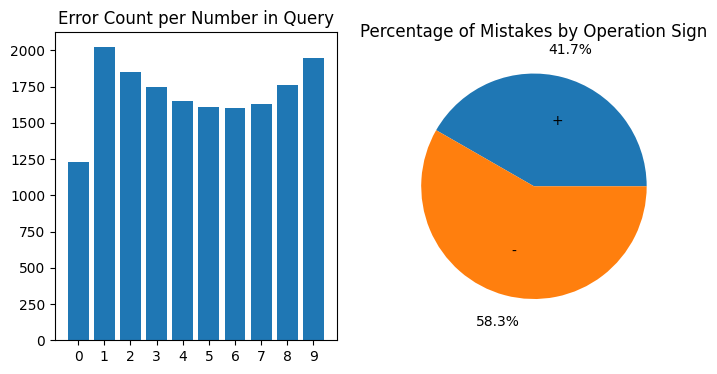

In [92]:
t2t_preds = t2t_model.predict(X_test_txt)
error_counter, error_in = plotter_1(X_test_txt, y_test_txt, t2t_preds)

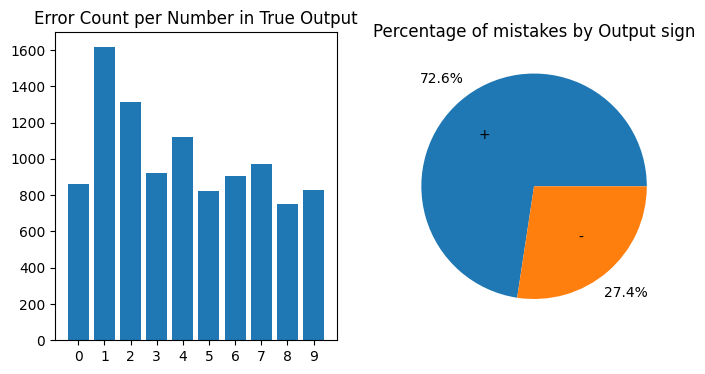

In [93]:
_, error_out = plotter_2(y_test_txt, t2t_preds)

In [94]:
print(error_counter)
print(error_in)
print(error_out)

5296
[1231 2023 1851 1748 1649 1612 1604 1631 1758 1947 2209 3087 1401]
[ 864 1617 1315  920 1118  823  908  970  749  827    0 1451 3361]


In [121]:
mean_absolute_error(y_test_txt, t2t_preds)

2.0701

### Test Size 0.75

In [122]:
## Your code (look at the assignment description for your tasks for text-to-text model):
## Your first task is to fit the text2text model using X_text and y_text)
X_train_txt, X_test_txt, y_train_txt, y_test_txt = train_test_split(X_text_onehot, y_text_onehot, test_size=0.75)

t2t_model = build_text2text_model()
#tensorboard_cb = keras.callbacks.TensorBoard(log_root())


t2t_model.fit(X_train_txt, y_train_txt, epochs=20)

/vol/home/s4431278/miniconda3/envs/idl/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_59 (LSTM)                  │ (None, 256)            │       276,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_17 (RepeatVector) │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_60 (LSTM)                  │ (None, 3, 256)         │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_17             │ (None, 3, 13)          │         3,341 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 805,133 (3.07 MB)

 Trainable params: 805,133 (3.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.2683 - loss: 2.2429
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.3959 - loss: 1.7718
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.4281 - loss: 1.6097
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4695 - loss: 1.4697
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.4956 - loss: 1.3920
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5257 - loss: 1.3100
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5377 - loss: 1.2516
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5558 - loss: 1.2051
Epoch 9/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5674 - loss: 1.1742
Epoch 10/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5743 - loss: 1.1610
Epoch 11/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5751 - loss: 1.1430
Epoch 12/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 

In [123]:
print(t2t_model.evaluate(X_test_txt, y_test_txt))

469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6181 - loss: 1.0288
[1.0232105255126953, 0.6208441257476807]


469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


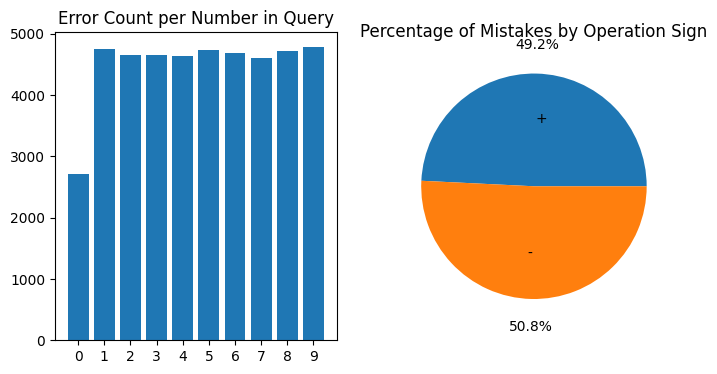

In [124]:
t2t_preds = t2t_model.predict(X_test_txt)
error_counter, error_in = plotter_1(X_test_txt, y_test_txt, t2t_preds)

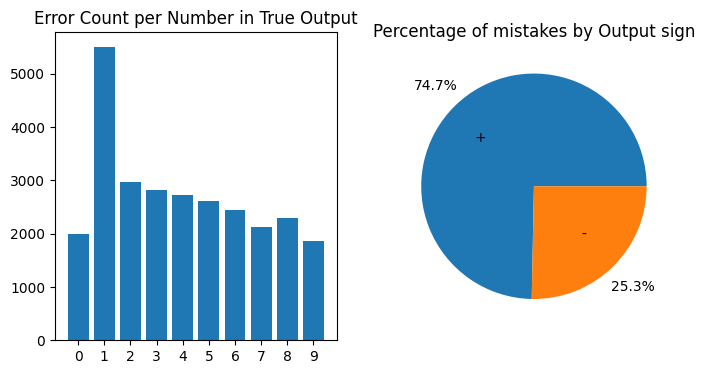

In [125]:
_, error_out = plotter_2(y_test_txt, t2t_preds)

In [126]:
print(error_counter)
print(error_in)
print(error_out)

13712
[2714 4756 4659 4653 4633 4734 4690 4612 4722 4785 6749 6963 2712]
[1989 5504 2975 2827 2717 2608 2447 2119 2300 1868    0 3471 7554]


In [127]:
print(mean_absolute_error(y_test_txt, t2t_preds))

6.832066666666667


### Test Size 0.9

In [128]:
## Your code (look at the assignment description for your tasks for text-to-text model):
## Your first task is to fit the text2text model using X_text and y_text)
X_train_txt, X_test_txt, y_train_txt, y_test_txt = train_test_split(X_text_onehot, y_text_onehot, test_size=0.9)

t2t_model = build_text2text_model()
#tensorboard_cb = keras.callbacks.TensorBoard(log_root())


t2t_model.fit(X_train_txt, y_train_txt, epochs=20)

/vol/home/s4431278/miniconda3/envs/idl/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_61 (LSTM)                  │ (None, 256)            │       276,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_18 (RepeatVector) │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_62 (LSTM)                  │ (None, 3, 256)         │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_18             │ (None, 3, 13)          │         3,341 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 805,133 (3.07 MB)

 Trainable params: 805,133 (3.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2324 - loss: 2.3774
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3658 - loss: 1.9946
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3960 - loss: 1.8189
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4056 - loss: 1.7240
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4216 - loss: 1.6322
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4408 - loss: 1.5602
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4548 - loss: 1.5044
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4735 - loss: 1.4610
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4911 - loss: 1.4105
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5090 - loss: 1.3610
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5228 - loss: 1.3200
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy:

In [129]:
print(t2t_model.evaluate(X_test_txt, y_test_txt))

563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5538 - loss: 1.2303
[1.2270468473434448, 0.5531851053237915]


563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


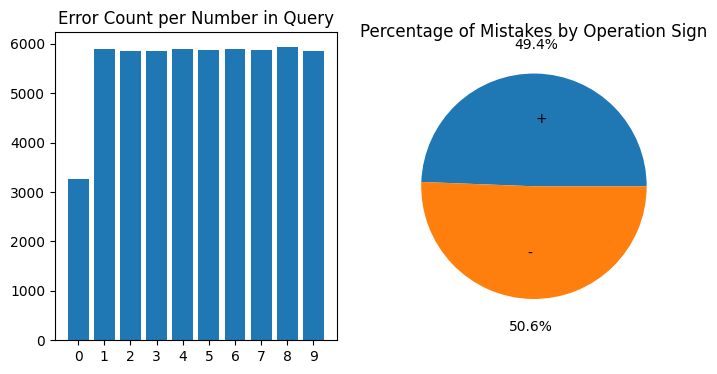

In [130]:
t2t_preds = t2t_model.predict(X_test_txt)
error_counter, error_in = plotter_1(X_test_txt, y_test_txt, t2t_preds)

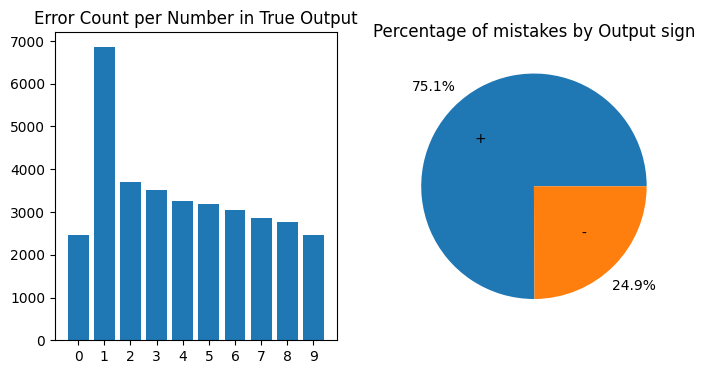

In [131]:
_, error_out = plotter_2(y_test_txt, t2t_preds)

In [132]:
print(error_counter)
print(error_in)
print(error_out)

17093
[3258 5900 5862 5850 5888 5874 5885 5869 5935 5854 8442 8651 3307]
[2454 6860 3693 3510 3250 3194 3044 2853 2776 2463    0 4261 9424]


In [135]:
print(mean_absolute_error(y_test_txt, t2t_preds))

8.047944444444445


### Extra LSTM Layers in Encoder

In [136]:
def build_text2text_model():

    # We start by initializing a sequential model
    text2text = tf.keras.Sequential()

    # "Encode" the input sequence using an RNN, producing an output of size 256.
    # In this case the size of our input vectors is [5, 13] as we have queries of length 5 and 13 unique characters. Each of these 5 elements in the query will be fed to the network one by one,
    # as shown in the image above (except with 5 elements).
    # Hint: In other applications, where your input sequences have a variable length (e.g. sentences), you would use input_shape=(None, unique_characters).
    text2text.add(LSTM(256, return_sequences=True, input_shape=(None, len(unique_characters))))
    text2text.add(LSTM(256, return_sequences=True))
    text2text.add(LSTM(256))

    # As the decoder RNN's input, repeatedly provide with the last output of RNN for each time step. Repeat 3 times as that's the maximum length of the output (e.g. '  1-99' = '-98')
    # when using 2-digit integers in queries. In other words, the RNN will always produce 3 characters as its output.
    text2text.add(RepeatVector(max_answer_length))

    # By setting return_sequences to True, return not only the last output but all the outputs so far in the form of (num_samples, timesteps, output_dim). This is necessary as TimeDistributed in the below expects
    # the first dimension to be the timesteps.
    text2text.add(LSTM(256, return_sequences=True))

    # Apply a dense layer to the every temporal slice of an input. For each of step of the output sequence, decide which character should be chosen.
    text2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

    # Next we compile the model using categorical crossentropy as our loss function.
    text2text.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    text2text.summary()

    return text2text

In [137]:
## Your code (look at the assignment description for your tasks for text-to-text model):
## Your first task is to fit the text2text model using X_text and y_text)
X_train_txt, X_test_txt, y_train_txt, y_test_txt = train_test_split(X_text_onehot, y_text_onehot, test_size=0.75)

t2t_model = build_text2text_model()
#tensorboard_cb = keras.callbacks.TensorBoard(log_root())


t2t_model.fit(X_train_txt, y_train_txt, epochs=20)

/vol/home/s4431278/miniconda3/envs/idl/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_63 (LSTM)                  │ (None, None, 256)      │       276,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_64 (LSTM)                  │ (None, None, 256)      │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_65 (LSTM)                  │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_19 (RepeatVector) │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_66 (LSTM)                  │ (None, 3, 256)         │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_19             │ (None, 3, 13)          │         3,341 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,855,757 (7.08 MB)

 Trainable params: 1,855,757 (7.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.2636 - loss: 2.2552
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.3928 - loss: 1.8141
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.4281 - loss: 1.6075
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.4941 - loss: 1.4189
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.5289 - loss: 1.2784
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.5716 - loss: 1.1666
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.5947 - loss: 1.0953
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.6116 - loss: 1.0426
Epoch 9/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.6180 - loss: 1.0183
Epoch 10/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.6174 - loss: 1.0130
Epoch 11/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.6259 - loss: 0.9893
Epoch 12/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 

In [138]:
print(t2t_model.evaluate(X_test_txt, y_test_txt))

469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.6849 - loss: 0.8280
[0.830359935760498, 0.6824889779090881]


469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step


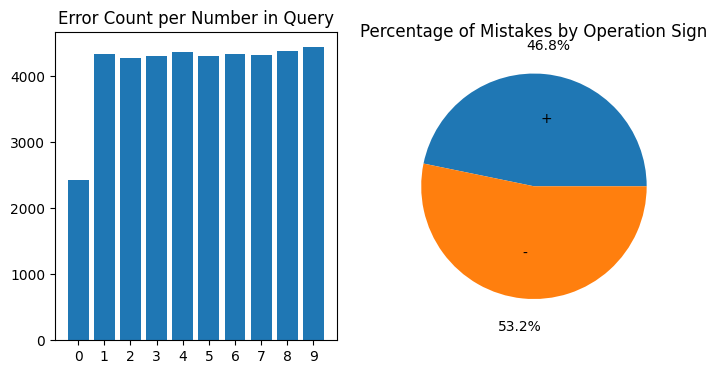

In [139]:
t2t_preds = t2t_model.predict(X_test_txt)
error_counter, error_in = plotter_1(X_test_txt, y_test_txt, t2t_preds)

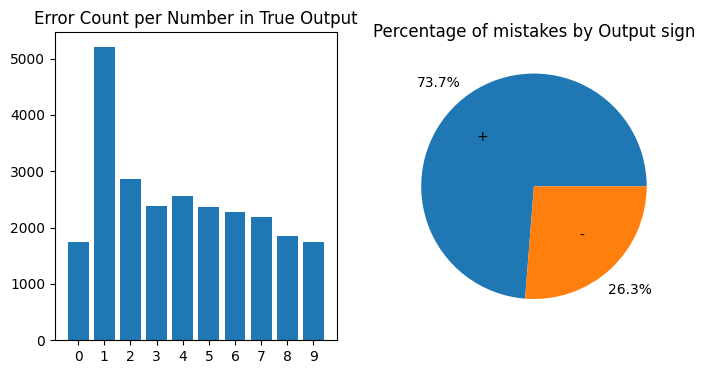

In [140]:
_, error_out = plotter_2(y_test_txt, t2t_preds)

In [141]:
print(error_counter)
print(error_in)
print(error_out)

12658
[2428 4330 4278 4304 4362 4312 4332 4325 4384 4443 5920 6738 2565]
[1736 5206 2856 2387 2569 2365 2278 2194 1851 1743    0 3323 6901]


In [142]:
print(mean_absolute_error(y_test_txt, t2t_preds))

3.7737333333333334



---
---

## II. Image to text RNN Model

Hint: There are two ways of building the encoder for such a model - again by using the regular LSTM cells (with flattened images as input vectors) or recurrect convolutional layers [ConvLSTM2D](https://keras.io/api/layers/recurrent_layers/conv_lstm2d/).

The goal here is to use **X_img** as inputs and **y_text** as outputs.

In [168]:
## Your code
def build_img2text_model_flat():

    # We start by initializing a sequential model
    img2text = tf.keras.Sequential()
    img2text.add(Input(shape=(max_query_length, *MNIST_data.shape[1:])))
    # "Encode" the input sequence using an RNN, producing an output of size 256.
    # In this case the size of our input vectors is [5, 13] as we have queries of length 5 and 13 unique characters. Each of these 5 elements in the query will be fed to the network one by one,
    # as shown in the image above (except with 5 elements).
    # Hint: In other applications, where your input sequences have a variable length (e.g. sentences), you would use input_shape=(None, unique_characters).
    img2text.add(Reshape((5, 28*28)))
    img2text.add(LSTM(256, return_sequences=True, activation='relu'))
    img2text.add(Dropout(0.5))
    img2text.add(LSTM(256, return_sequences=True, activation='relu'))
    img2text.add(Dropout(0.5))
    img2text.add(LSTM(256, activation='relu'))
    img2text.add(Dropout(0.5))
    #img2text.add(LSTM(256))
    img2text.add(RepeatVector(max_answer_length))

    # By setting return_sequences to True, return not only the last output but all the outputs so far in the form of (num_samples, timesteps, output_dim). This is necessary as TimeDistributed in the below expects
    # the first dimension to be the timesteps.
    img2text.add(LSTM(512, return_sequences=True))
    img2text.add(Dropout(0.5))
    img2text.add(BatchNormalization())
    img2text.add(LSTM(512, return_sequences=True))
    img2text.add(Dropout(0.5))
    img2text.add(BatchNormalization())
    img2text.add(LSTM(512, return_sequences=True))
    img2text.add(Dropout(0.5))
    img2text.add(BatchNormalization())
    img2text.add(LSTM(512, return_sequences=True))
    img2text.add(Dropout(0.5))
    img2text.add(BatchNormalization())
    img2text.add(LSTM(512, return_sequences=True))
    img2text.add(Dropout(0.5))
    img2text.add(BatchNormalization())
    

    # Apply a dense layer to the every temporal slice of an input. For each of step of the output sequence, decide which character should be chosen.
    img2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

    # Next we compile the model using categorical crossentropy as our loss function.
    img2text.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    img2text.summary()

    return img2text




In [144]:
## Your code
def build_img2text_model_convlstm():

    # We start by initializing a sequential model
    img2text = tf.keras.Sequential()
    img2text.add(Input(shape=(max_query_length, *MNIST_data.shape[1:], 1)))
    # "Encode" the input sequence using an RNN, producing an output of size 256.
    # In this case the size of our input vectors is [5, 13] as we have queries of length 5 and 13 unique characters. Each of these 5 elements in the query will be fed to the network one by one,
    # as shown in the image above (except with 5 elements).
    # Hint: In other applications, where your input sequences have a variable length (e.g. sentences), you would use input_shape=(None, unique_characters).
    img2text.add(ConvLSTM2D(32, (3,3), padding="same", activation='relu', return_sequences=True))
    img2text.add(BatchNormalization())
    img2text.add(MaxPooling3D((1,2,2)))
    img2text.add(ConvLSTM2D(64, (3,3), padding="same", activation='relu', return_sequences=True))
    img2text.add(MaxPooling3D((1,2,2)))
    img2text.add(BatchNormalization())
    img2text.add(ConvLSTM2D(128, (3,3), padding="same", activation='relu'))
    img2text.add(MaxPooling2D((2,2)))
    img2text.add(BatchNormalization())
    img2text.add(Flatten())
    
    # As the decoder RNN's input, repeatedly provide with the last output of RNN for each time step. Repeat 3 times as that's the maximum length of the output (e.g. '  1-99' = '-98')
    # when using 2-digit integers in queries. In other words, the RNN will always produce 3 characters as its output.
    img2text.add(RepeatVector(max_answer_length))

    # By setting return_sequences to True, return not only the last output but all the outputs so far in the form of (num_samples, timesteps, output_dim). This is necessary as TimeDistributed in the below expects
    # the first dimension to be the timesteps.
    img2text.add(LSTM(512, return_sequences=True, activation='relu'))
    img2text.add(Dropout(0.5))
    img2text.add(LSTM(512, return_sequences=True, activation='relu'))
    img2text.add(Dropout(0.5))
    img2text.add(LSTM(512, return_sequences=True, activation='relu'))
    img2text.add(Dropout(0.5))
    img2text.add(LSTM(512, return_sequences=True, activation='relu'))
    img2text.add(Dropout(0.5))
    img2text.add(LSTM(512, return_sequences=True, activation='relu'))
    img2text.add(Dropout(0.5))
    

    # Apply a dense layer to the every temporal slice of an input. For each of step of the output sequence, decide which character should be chosen.
    img2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

    # Next we compile the model using categorical crossentropy as our loss function.
    img2text.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    img2text.summary()

    return img2text




### Training and results

In [169]:
## Your code (look at the assignment description for your tasks for text-to-text model):
## Your first task is to fit the text2text model using X_text and y_text)
X_train_img, X_test_img, y_train_txt, y_test_txt, X_train_txt, X_test_txt = train_test_split(X_img, y_text_onehot, X_text_onehot, test_size=0.2)
X_train_img, X_val_img, y_train_txt, y_val_txt = train_test_split(X_train_img, y_train_txt, test_size=0.2)

i2t_model = build_img2text_model_flat()
#tensorboard_cb = keras.callbacks.TensorBoard(log_root())
es_callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
hist = i2t_model.fit(X_train_img, y_train_txt, validation_data=(X_val_img, y_val_txt), epochs=100, callbacks=[es_callback])

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 5, 784)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_87 (LSTM)                  │ (None, 5, 256)         │     1,065,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_55 (Dropout)            │ (None, 5, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_88 (LSTM)                  │ (None, 5, 256)         │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_56 (Dropout)            │ (None, 5, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_89 (LSTM)                  │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_24 (RepeatVector) │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_90 (LSTM)                  │ (None, 3, 512)         │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_58 (Dropout)            │ (None, 3, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ (None, 3, 512)         │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_91 (LSTM)                  │ (None, 3, 512)         │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_59 (Dropout)            │ (None, 3, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 3, 512)         │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_92 (LSTM)                  │ (None, 3, 512)         │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 3, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 3, 512)         │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_93 (LSTM)                  │ (None, 3, 512)         │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_61 (Dropout)            │ (None, 3, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 3, 512)         │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_94 (LSTM)                  │ (None, 3, 512)         │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_62 (Dropout)            │ (None, 3, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 3, 512)         │         2,04

 Total params: 12,105,229 (46.18 MB)

 Trainable params: 12,100,109 (46.16 MB)

 Non-trainable params: 5,120 (20.00 KB)

Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.2203 - loss: 2.6955 - val_accuracy: 0.3818 - val_loss: 2.0158
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.3728 - loss: 2.0745 - val_accuracy: 0.3879 - val_loss: 1.9004
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.3831 - loss: 1.9081 - val_accuracy: 0.4016 - val_loss: 1.7500
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.3933 - loss: 1.7882 - val_accuracy: 0.4007 - val_loss: 1.7639
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.4057 - loss: 1.7148 - val_accuracy: 0.4168 - val_loss: 1.6675
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.4137 - loss: 1.6717 - val_accuracy: 0.4252 - val_loss: 1.6275
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.4267 - loss: 1.6190 - val_accuracy: 0.4323 - val_loss: 1.5962
Epoch 8/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.4280 - loss: 1

In [170]:
print(i2t_model.evaluate(X_test_img, y_test_txt))

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4749 - loss: 1.5149
[1.5162818431854248, 0.476083368062973]


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


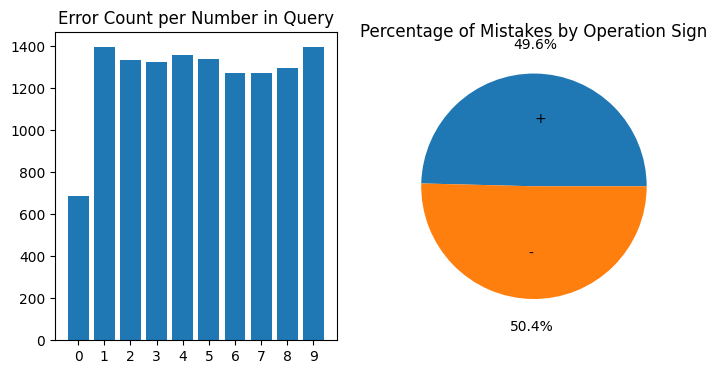

In [171]:
i2t_preds = i2t_model.predict(X_test_img)
for i in range(i2t_preds.shape[0]):
    for t in range(3):
        pred = np.argmax(i2t_preds[i,t,:])
        i2t_preds[i,t,:] *= 0
        i2t_preds[i,t,pred] = 1
error_counter, error_in = plotter_1(X_test_txt, y_test_txt, i2t_preds)

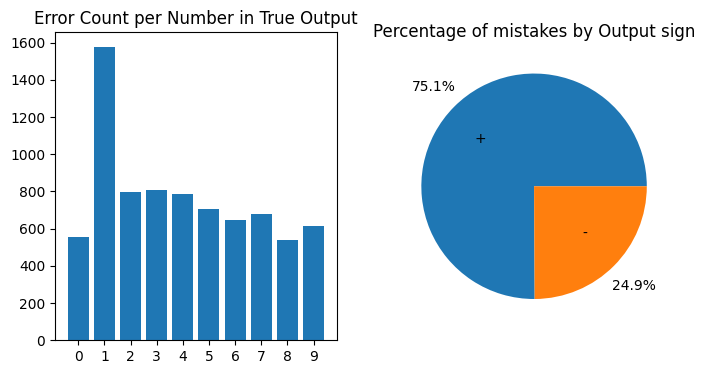

In [172]:
_, error_out = plotter_2(y_test_txt, i2t_preds)

In [173]:
print(error_counter)
print(error_in)
print(error_out)

3861
[ 689 1395 1334 1323 1359 1341 1272 1273 1298 1396 1915 1946  729]
[ 556 1577  795  809  784  708  647  680  537  614    0  962 2141]


In [174]:
print(mean_absolute_error(y_test_txt, i2t_preds))

11.5


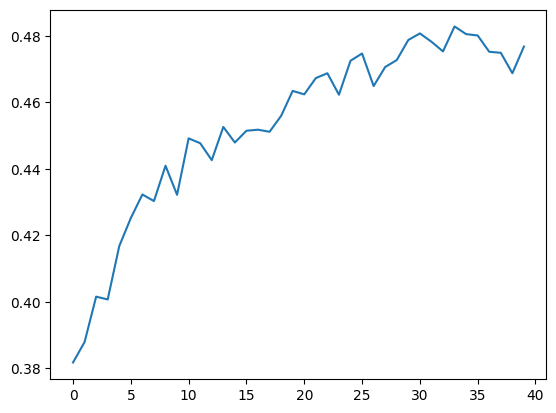

In [175]:
plt.plot(hist.history["val_accuracy"])

In [161]:
i2t_model = build_img2text_model_convlstm()

es_callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
hist = i2t_model.fit(X_train_img, y_train_txt, validation_data=(X_val_img, y_val_txt), epochs=100, callbacks=[es_callback])

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d_12 (ConvLSTM2D)     │ (None, 5, 28, 28, 32)  │        38,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 5, 28, 28, 32)  │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_7 (MaxPooling3D)  │ (None, 5, 14, 14, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_13 (ConvLSTM2D)     │ (None, 5, 14, 14, 64)  │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_8 (MaxPooling3D)  │ (None, 5, 7, 7, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 5, 7, 7, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_14 (ConvLSTM2D)     │ (None, 7, 7, 128)      │       885,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_23 (RepeatVector) │ (None, 3, 1152)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_82 (LSTM)                  │ (None, 3, 512)         │     3,409,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 3, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_83 (LSTM)                  │ (None, 3, 512)         │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 3, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_84 (LSTM)                  │ (None, 3, 512)         │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 3, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_85 (LSTM)                  │ (None, 3, 512)         │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 3, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_86 (LSTM)                  │ (None, 3, 512)         │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_54 (Dropout)            │ (None, 3, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_23             │ (None, 3, 13)          │         6,669 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,959,117 (49.44 MB)

 Trainable params: 12,958,669 (49.43 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 67s 156ms/step - accuracy: 0.2731 - loss: 2.2473 - val_accuracy: 0.3204 - val_loss: 2.1012
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 71s 177ms/step - accuracy: 0.3423 - loss: 1.9401 - val_accuracy: 0.3906 - val_loss: 1.8820
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 75s 187ms/step - accuracy: 0.3976 - loss: 1.7580 - val_accuracy: 0.4117 - val_loss: 1.6620
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 75s 187ms/step - accuracy: 0.4117 - loss: 1.6722 - val_accuracy: 0.4201 - val_loss: 1.6409
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 75s 187ms/step - accuracy: 0.4279 - loss: 1.6048 - val_accuracy: 0.4064 - val_loss: 1.7045
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 75s 186ms/step - accuracy: 0.4398 - loss: 1.5619 - val_accuracy: 0.4301 - val_loss: 1.5967
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 75s 186ms/step - accuracy: 0.4452 - loss: 1.5154 - val_accuracy: 0.4316 - val_loss: 1.5648
Epoch 8/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 75s 187ms/step - accuracy: 0.4539 -

In [162]:
print(i2t_model.evaluate(X_test_img, y_test_txt))

125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.5000 - loss: 1.5237
[1.5258194208145142, 0.4991666376590729]


125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step


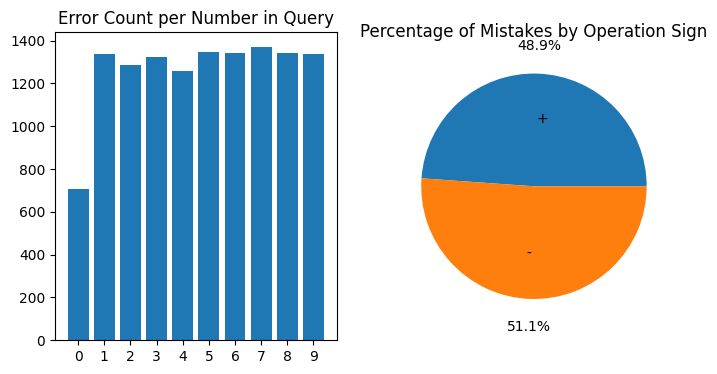

In [163]:
i2t_preds = i2t_model.predict(X_test_img)
for i in range(i2t_preds.shape[0]):
    for t in range(3):
        pred = np.argmax(i2t_preds[i,t,:])
        i2t_preds[i,t,:] *= 0
        i2t_preds[i,t,pred] = 1
error_counter, error_in = plotter_1(X_test_txt, y_test_txt, i2t_preds)

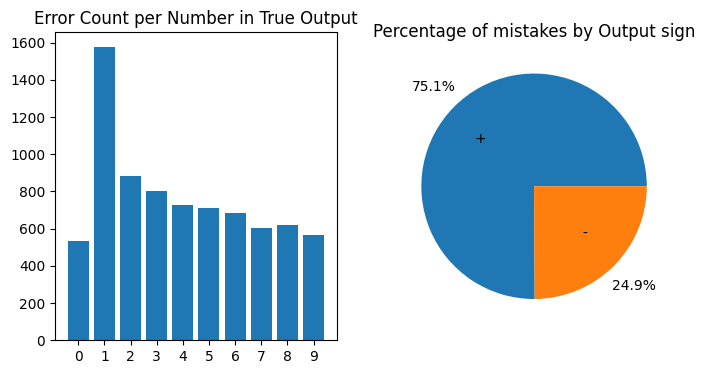

In [164]:
_, error_out = plotter_2(y_test_txt, i2t_preds)

In [165]:
print(error_counter)
print(error_in)
print(error_out)

3869
[ 708 1338 1286 1325 1257 1346 1343 1370 1342 1335 1891 1978  706]
[ 534 1577  884  805  726  711  685  603  619  566    0  964 2139]


In [166]:
print(mean_absolute_error(y_test_txt, i2t_preds))

9.8225


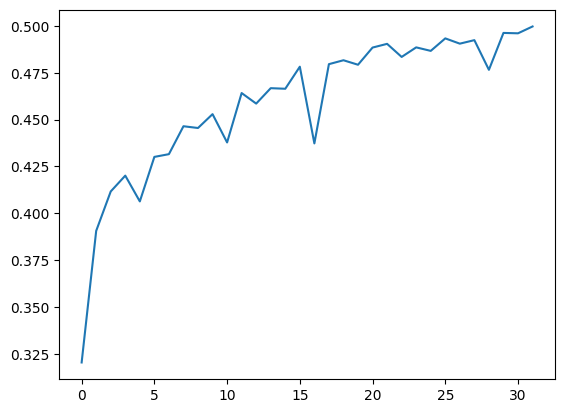

In [167]:
plt.plot(hist.history["val_accuracy"])

### Extra LSTM in Encoder

In [176]:
## Your code
def build_img2text_model_flat_extra():

    # We start by initializing a sequential model
    img2text = tf.keras.Sequential()
    img2text.add(Input(shape=(max_query_length, *MNIST_data.shape[1:])))
    # "Encode" the input sequence using an RNN, producing an output of size 256.
    # In this case the size of our input vectors is [5, 13] as we have queries of length 5 and 13 unique characters. Each of these 5 elements in the query will be fed to the network one by one,
    # as shown in the image above (except with 5 elements).
    # Hint: In other applications, where your input sequences have a variable length (e.g. sentences), you would use input_shape=(None, unique_characters).
    img2text.add(Reshape((5, 28*28)))
    img2text.add(LSTM(256, return_sequences=True, activation='relu'))
    img2text.add(Dropout(0.5))
    img2text.add(LSTM(256, return_sequences=True, activation='relu'))
    img2text.add(Dropout(0.5))
    img2text.add(LSTM(256, return_sequences=True, activation='relu'))
    img2text.add(Dropout(0.5))
    img2text.add(LSTM(256, return_sequences=True, activation='relu'))
    img2text.add(Dropout(0.5))
    img2text.add(LSTM(256, activation='relu'))
    img2text.add(Dropout(0.5))
    #img2text.add(LSTM(256))
    img2text.add(RepeatVector(max_answer_length))

    # By setting return_sequences to True, return not only the last output but all the outputs so far in the form of (num_samples, timesteps, output_dim). This is necessary as TimeDistributed in the below expects
    # the first dimension to be the timesteps.
    img2text.add(LSTM(512, return_sequences=True))
    img2text.add(Dropout(0.5))
    img2text.add(BatchNormalization())
    img2text.add(LSTM(512, return_sequences=True))
    img2text.add(Dropout(0.5))
    img2text.add(BatchNormalization())
    img2text.add(LSTM(512, return_sequences=True))
    img2text.add(Dropout(0.5))
    img2text.add(BatchNormalization())
    img2text.add(LSTM(512, return_sequences=True))
    img2text.add(Dropout(0.5))
    img2text.add(BatchNormalization())
    img2text.add(LSTM(512, return_sequences=True))
    img2text.add(Dropout(0.5))
    img2text.add(BatchNormalization())
    

    # Apply a dense layer to the every temporal slice of an input. For each of step of the output sequence, decide which character should be chosen.
    img2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

    # Next we compile the model using categorical crossentropy as our loss function.
    img2text.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    img2text.summary()

    return img2text




In [177]:
i2t_model = build_img2text_model_flat_extra()
#tensorboard_cb = keras.callbacks.TensorBoard(log_root())
es_callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
hist = i2t_model.fit(X_train_img, y_train_txt, validation_data=(X_val_img, y_val_txt), epochs=100, callbacks=[es_callback])

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 5, 784)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_95 (LSTM)                  │ (None, 5, 256)         │     1,065,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 5, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_96 (LSTM)                  │ (None, 5, 256)         │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 5, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_97 (LSTM)                  │ (None, 5, 256)         │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 5, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_98 (LSTM)                  │ (None, 5, 256)         │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 5, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_99 (LSTM)                  │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_25 (RepeatVector) │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_100 (LSTM)                 │ (None, 3, 512)         │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 3, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 3, 512)         │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_101 (LSTM)                 │ (None, 3, 512)         │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 3, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 3, 512)         │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_102 (LSTM)                 │ (None, 3, 512)         │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 3, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (None, 3, 512)         │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_103 (LSTM)                 │ (None, 3, 512)         │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_71 (Dropout)            │ (None, 3, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 13,155,853 (50.19 MB)

 Trainable params: 13,150,733 (50.17 MB)

 Non-trainable params: 5,120 (20.00 KB)

Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 31s 67ms/step - accuracy: 0.2073 - loss: 2.7366 - val_accuracy: 0.3280 - val_loss: 2.0960
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.3080 - loss: 2.1668 - val_accuracy: 0.3336 - val_loss: 2.0554
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.3188 - loss: 2.1056 - val_accuracy: 0.3336 - val_loss: 2.0521
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.3206 - loss: 2.0872 - val_accuracy: 0.3272 - val_loss: 2.0536
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - accuracy: 0.3216 - loss: 2.0773 - val_accuracy: 0.3264 - val_loss: 2.0526
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.3206 - loss: 2.0743 - val_accuracy: 0.3280 - val_loss: 2.0433
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - accuracy: 0.3262 - loss: 2.0699 - val_accuracy: 0.3280 - val_loss: 2.0460
Epoch 8/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - accuracy: 0.3241 - loss: 2

In [178]:
print(i2t_model.evaluate(X_test_img, y_test_txt))

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.3273 - loss: 2.0356
[2.0353665351867676, 0.3255833387374878]


125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step


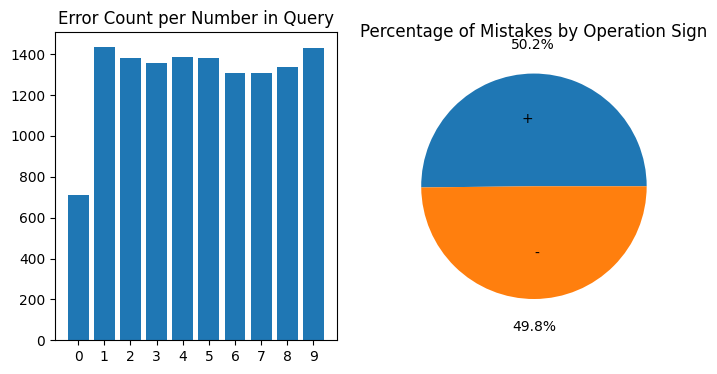

In [179]:
i2t_preds = i2t_model.predict(X_test_img)
for i in range(i2t_preds.shape[0]):
    for t in range(3):
        pred = np.argmax(i2t_preds[i,t,:])
        i2t_preds[i,t,:] *= 0
        i2t_preds[i,t,pred] = 1
error_counter, error_in = plotter_1(X_test_txt, y_test_txt, i2t_preds)

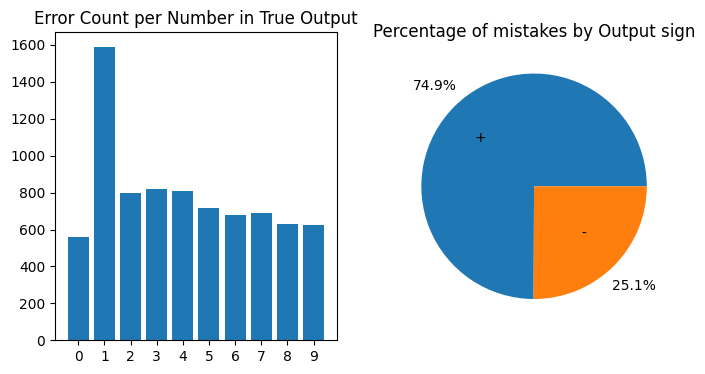

In [180]:
_, error_out = plotter_2(y_test_txt, i2t_preds)

In [181]:
print(error_counter)
print(error_in)
print(error_out)

3969
[ 712 1435 1379 1357 1385 1379 1306 1308 1338 1430 1991 1978  754]
[ 560 1589  800  820  808  719  678  688  631  624    0  995 2191]


In [182]:
print(mean_absolute_error(y_test_txt, i2t_preds))

60.8605


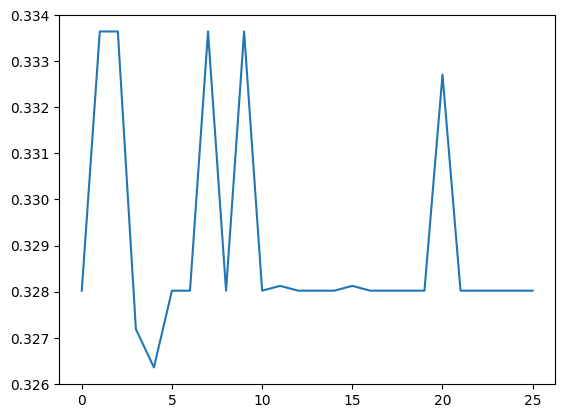

In [183]:
plt.plot(hist.history["val_accuracy"])

---
---

## III. Text to image RNN Model

Hint: to make this model work really well you could use deconvolutional layers in your decoder (you might need to look up ***Conv2DTranspose*** layer). However, regular vector-based decoder will work as well.

The goal here is to use **X_text** as inputs and **y_img** as outputs.

In [184]:
# Your code
def build_text2img_model():

    # We start by initializing a sequential model
    txt2img = tf.keras.Sequential()
    txt2img.add(LSTM(256, return_sequences=True, input_shape=(None, len(unique_characters)), activation='relu'))
    txt2img.add(LSTM(256, return_sequences=True, activation='relu'))
    txt2img.add(LSTM(256, activation='relu'))

    txt2img.add(RepeatVector(max_answer_length))

    txt2img.add(LSTM(784, return_sequences=True, activation='relu'))#TODO add more lstm layers here (might need remove a 2d transpose, unsure)
    txt2img.add(Reshape((3, 28, 28)))

    txt2img.add(Conv2DTranspose(128, (3,3), padding="same", data_format="channels_first", activation='relu'))
    txt2img.add(Conv2DTranspose(64, (3,3), padding="same", data_format="channels_first", activation='relu'))
    txt2img.add(Conv2DTranspose(32, (3,3), padding="same", data_format="channels_first", activation='relu'))
    txt2img.add(Conv2DTranspose(3, (3,3), padding="same", data_format="channels_first", activation='sigmoid'))

    #txt2img.add(Reshape((3, 28, 28)))

    txt2img.compile(loss="mse", optimizer='adam', metrics=['mean_absolute_error'])
    txt2img.summary()
    
    return txt2img



In [185]:
# Your code
def build_text2img_model_ExtraLstm():

    # We start by initializing a sequential model
    txt2img = tf.keras.Sequential()
    txt2img.add(LSTM(256, return_sequences=True, input_shape=(None, len(unique_characters)), activation='relu'))
    txt2img.add(LSTM(256, return_sequences=True, activation='relu'))
    txt2img.add(LSTM(256, return_sequences=True, activation='relu'))
    txt2img.add(LSTM(256, return_sequences=True, activation='relu'))
    txt2img.add(LSTM(256, return_sequences=True, activation='relu'))
    txt2img.add(LSTM(256, activation='relu'))

    txt2img.add(RepeatVector(max_answer_length))

    txt2img.add(LSTM(784, return_sequences=True, activation='relu'))#TODO add more lstm layers here (might need remove a 2d transpose, unsure)
    txt2img.add(Reshape((3, 28, 28)))

    txt2img.add(Conv2DTranspose(128, (3,3), padding="same", data_format="channels_first", activation='relu'))
    txt2img.add(Conv2DTranspose(64, (3,3), padding="same", data_format="channels_first", activation='relu'))
    txt2img.add(Conv2DTranspose(32, (3,3), padding="same", data_format="channels_first", activation='relu'))
    txt2img.add(Conv2DTranspose(3, (3,3), padding="same", data_format="channels_first", activation='sigmoid'))

    #txt2img.add(Reshape((3, 28, 28)))

    txt2img.compile(loss="mse", optimizer='adam', metrics=['mean_absolute_error'])
    txt2img.summary()
    
    return txt2img



In [226]:
X_train_txt, X_test_txt, y_train_img, y_test_img, y_train_txt, y_test_txt = train_test_split(X_text_onehot, y_img, y_text_onehot, test_size=0.2)
X_train_txt, X_val_txt, y_train_img, y_val_img = train_test_split(X_train_txt, y_train_img, test_size=0.2)

t2i_model = build_text2img_model()

t2i_model.fit(X_train_txt, y_train_img, validation_data=(X_val_txt, y_val_img), epochs=50)

/vol/home/s4431278/miniconda3/envs/idl/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_132 (LSTM)                 │ (None, None, 256)      │       276,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_133 (LSTM)                 │ (None, None, 256)      │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_134 (LSTM)                 │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_29 (RepeatVector) │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_135 (LSTM)                 │ (None, 3, 784)         │     3,264,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_8 (Reshape)             │ (None, 3, 28, 28)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_12             │ (None, 128, 28, 28)    │         3,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_13             │ (None, 64, 28, 28)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_14             │ (None, 32, 28, 28)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_15             │ (None, 3, 28, 28)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,688,387 (17.88 MB)

 Trainable params: 4,688,387 (17.88 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 46s 112ms/step - loss: 0.0966 - mean_absolute_error: 0.1459 - val_loss: 0.0552 - val_mean_absolute_error: 0.1227
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 44s 110ms/step - loss: 0.0548 - mean_absolute_error: 0.1204 - val_loss: 0.0531 - val_mean_absolute_error: 0.1172
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 45s 111ms/step - loss: 0.0518 - mean_absolute_error: 0.1144 - val_loss: 0.0490 - val_mean_absolute_error: 0.1062
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 45s 112ms/step - loss: 0.0490 - mean_absolute_error: 0.1085 - val_loss: 0.0481 - val_mean_absolute_error: 0.1043
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 44s 110ms/step - loss: 0.0482 - mean_absolute_error: 0.1071 - val_loss: 0.0478 - val_mean_absolute_error: 0.1037
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 45s 111ms/step - loss: 0.0479 - mean_absolute_error: 0.1063 - val_loss: 0.0477 - val_mean_absolute_error: 0.1054
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 44s 111ms/step - loss: 0.0477 - mean_absol

In [227]:
t2i_model_extra = build_text2img_model_ExtraLstm()

t2i_model_extra.fit(X_train_txt, y_train_img, validation_data=(X_val_txt, y_val_img), epochs=50)

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_136 (LSTM)                 │ (None, None, 256)      │       276,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_137 (LSTM)                 │ (None, None, 256)      │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_138 (LSTM)                 │ (None, None, 256)      │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_139 (LSTM)                 │ (None, None, 256)      │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_140 (LSTM)                 │ (None, None, 256)      │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_141 (LSTM)                 │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_30 (RepeatVector) │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_142 (LSTM)                 │ (None, 3, 784)         │     3,264,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_9 (Reshape)             │ (None, 3, 28, 28)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_16             │ (None, 128, 28, 28)    │         3,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_17             │ (None, 64, 28, 28)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_18             │ (None, 32, 28, 28)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_19             │ (None, 3, 28, 28)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,264,323 (23.90 MB)

 Trainable params: 6,264,323 (23.90 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 56s 133ms/step - loss: 0.0887 - mean_absolute_error: 0.1547 - val_loss: 0.0547 - val_mean_absolute_error: 0.1203
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 52s 131ms/step - loss: 0.0546 - mean_absolute_error: 0.1207 - val_loss: 0.0544 - val_mean_absolute_error: 0.1209
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 52s 130ms/step - loss: 0.0542 - mean_absolute_error: 0.1202 - val_loss: 0.0530 - val_mean_absolute_error: 0.1227
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 52s 130ms/step - loss: 0.0518 - mean_absolute_error: 0.1153 - val_loss: 0.0490 - val_mean_absolute_error: 0.1077
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 52s 130ms/step - loss: 0.0491 - mean_absolute_error: 0.1098 - val_loss: 0.0484 - val_mean_absolute_error: 0.1047
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 52s 131ms/step - loss: 0.0484 - mean_absolute_error: 0.1078 - val_loss: 0.0477 - val_mean_absolute_error: 0.1042
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 53s 132ms/step - loss: 0.0478 - mean_absol

### Some output examples

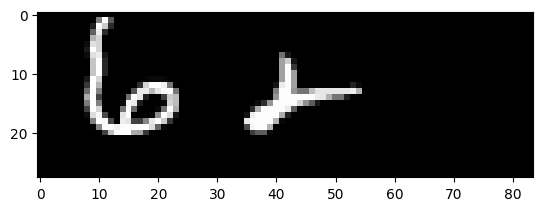

In [195]:
plt.imshow(np.hstack((y_train_img[0,0], y_train_img[0,1], y_train_img[0,2])), cmap="gray")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
(3, 28, 28)


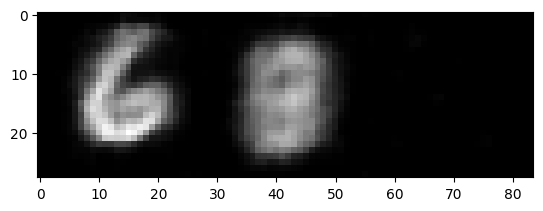

In [196]:
yhat = t2i_model.predict(X_train_txt[:2,:])[0,:]
print(yhat.shape)
plt.imshow(np.hstack((yhat[0,:], yhat[1,:], yhat[2,:])), cmap="gray")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
(3, 28, 28)


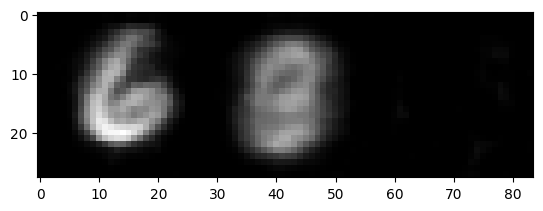

In [197]:
yhat = t2i_model_extra.predict(X_train_txt[:2,:])[0,:]
print(yhat.shape)
plt.imshow(np.hstack((yhat[0,:], yhat[1,:], yhat[2,:])), cmap="gray")

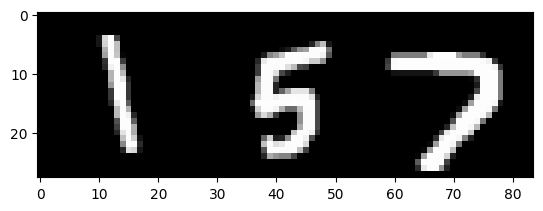

In [198]:
plt.imshow(np.hstack((y_train_img[1,0], y_train_img[1,1], y_train_img[1,2])), cmap="gray")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


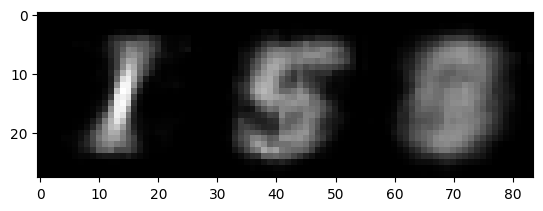

In [199]:
yhat = t2i_model.predict(X_train_txt[:2,:])[1,:]
plt.imshow(np.hstack((yhat[0,:], yhat[1,:], yhat[2,:])), cmap="gray")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


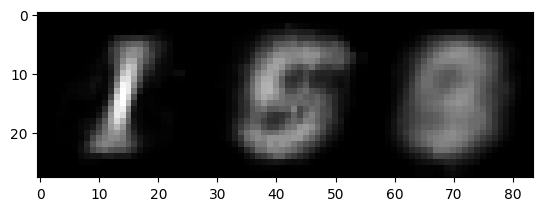

In [200]:
yhat = t2i_model_extra.predict(X_train_txt[:2,:])[1,:]
plt.imshow(np.hstack((yhat[0,:], yhat[1,:], yhat[2,:])), cmap="gray")

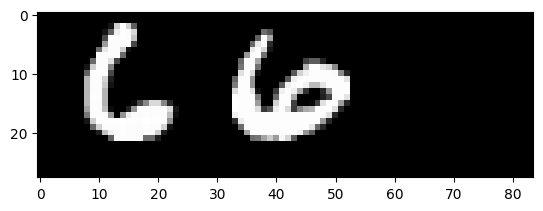

In [201]:
plt.imshow(np.hstack((y_val_img[1,0], y_val_img[1,1], y_val_img[1,2])), cmap="gray")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


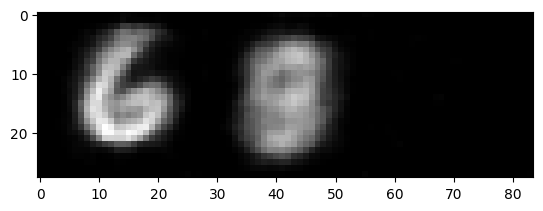

In [202]:
yhat = t2i_model.predict(X_val_txt[:2,:])[1,:]
plt.imshow(np.hstack((yhat[0,:], yhat[1,:], yhat[2,:])), cmap="gray")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


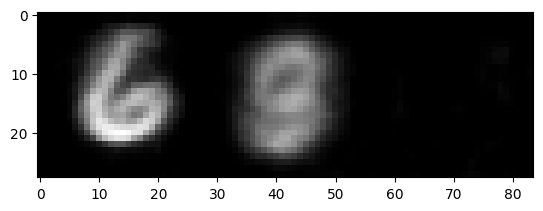

In [203]:
yhat = t2i_model_extra.predict(X_val_txt[:2,:])[1,:]
plt.imshow(np.hstack((yhat[0,:], yhat[1,:], yhat[2,:])), cmap="gray")

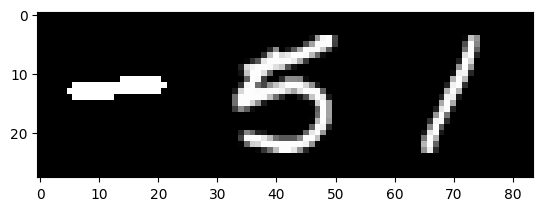

In [204]:
plt.imshow(np.hstack((y_test_img[1,0], y_test_img[1,1], y_test_img[1,2])), cmap="gray")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


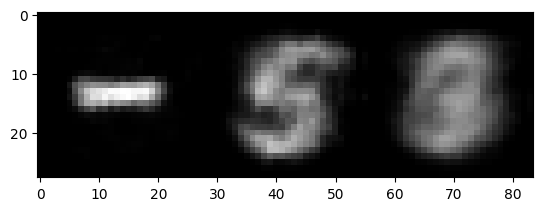

In [205]:
yhat = t2i_model.predict(X_test_txt[:2,:])[1,:]
plt.imshow(np.hstack((yhat[0,:], yhat[1,:], yhat[2,:])), cmap="gray")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


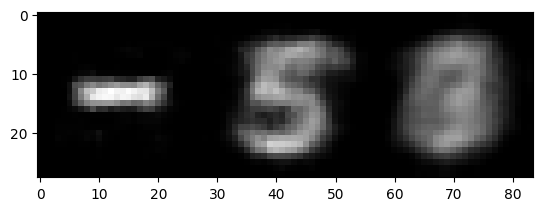

In [206]:
yhat = t2i_model_extra.predict(X_test_txt[:2,:])[1,:]
plt.imshow(np.hstack((yhat[0,:], yhat[1,:], yhat[2,:])), cmap="gray")

### Generated Image Classification Model

In [207]:
def build_discrim_model():

    # We start by initializing a sequential model
    discrim = tf.keras.Sequential()

    discrim.add(Input(shape=(3,28,28)))
    discrim.add(Reshape((3, 28 * 28)))
    discrim.add(LSTM(256, return_sequences=True, activation='relu'))
    discrim.add(LSTM(256, return_sequences=True, activation='relu'))
    discrim.add(LSTM(256, return_sequences=True, activation='relu'))

    discrim.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

    discrim.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])
    discrim.summary()
    
    return discrim

In [223]:
X_train_img, X_test_img, y_train_txt, y_test_txt = train_test_split(y_img, y_text_onehot, test_size=0.2)
discrim_model = build_discrim_model()

discrim_model.fit(X_train_img, y_train_txt, epochs=20)

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_7 (Reshape)             │ (None, 3, 784)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_129 (LSTM)                 │ (None, 3, 256)         │     1,065,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_130 (LSTM)                 │ (None, 3, 256)         │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_131 (LSTM)                 │ (None, 3, 256)         │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_28             │ (None, 3, 13)          │         3,341 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,119,949 (8.09 MB)

 Trainable params: 2,119,949 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6286 - loss: 1.1400
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9553 - loss: 0.1487
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9718 - loss: 0.0891
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9812 - loss: 0.0603
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9852 - loss: 0.0480
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9899 - loss: 0.0304
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9919 - loss: 0.0265
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9944 - loss: 0.0194
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9948 - loss: 0.0172
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9947 - loss: 0.0161
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9952 - loss: 0.0132
Epoch 12/20
500/500 ━━━━━━━━━━━━━

In [209]:
print(discrim_model.evaluate(X_test_img, y_test_txt))

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9832 - loss: 0.0902
[0.09572899341583252, 0.9822499752044678]


In [225]:
print(mean_absolute_error(y_test_txt, discrim_model.predict(X_test_img)))

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
1.73225


### Text To Image Model Evaluation

In [228]:
discrim_model.fit(y_img, y_text_onehot, epochs=20, callbacks=[es_callback])

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.9948 - loss: 0.0218
Epoch 2/20
 11/625 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9978 - loss: 0.0077

/vol/home/s4431278/miniconda3/envs/idl/lib/python3.12/site-packages/keras/src/callbacks/early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9974 - loss: 0.0089
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9985 - loss: 0.0047
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.9971 - loss: 0.0113
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9979 - loss: 0.0071
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9984 - loss: 0.0059
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9984 - loss: 0.0055
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9978 - loss: 0.0086
Epoch 9/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9990 - loss: 0.0039
Epoch 10/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9987 - loss: 0.0059
Epoch 11/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9994 - loss: 0.0020
Epoch 12/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.9982 - loss: 0.0072
Epoch 13/20
625/625 ━━━━━━━━━━━━━━━━━━━━

125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


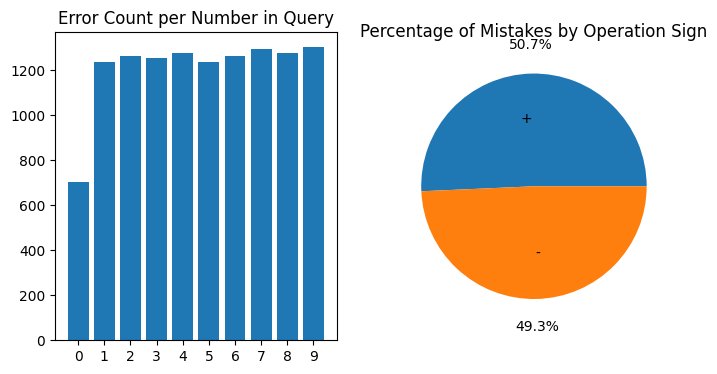

In [229]:
img_gen = t2i_model.predict(X_test_txt)
preds = discrim_model.predict(img_gen)
for i in range(preds.shape[0]):
    for t in range(3):
        pred = np.argmax(preds[i,t,:])
        preds[i,t,:] *= 0
        preds[i,t,pred] = 1

error_counter, error_in = plotter_1(X_test_txt, y_test_txt, preds)

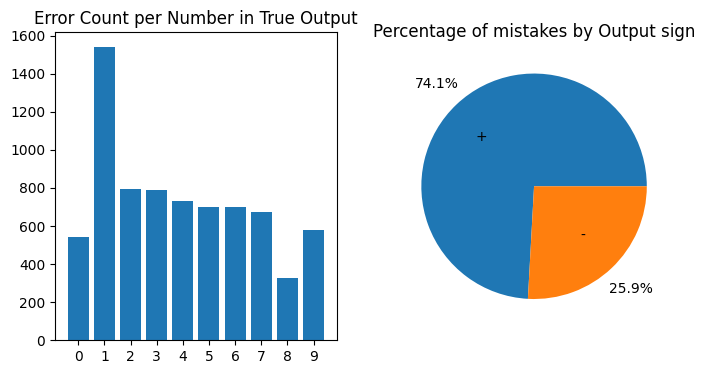

In [230]:
_, error_out = plotter_2(y_test_txt, preds)

In [231]:
print(error_counter)
print(error_in)
print(error_out)

3676
[ 704 1238 1263 1254 1278 1237 1264 1295 1279 1304 1864 1812  700]
[ 543 1540  793  790  733  702  701  676  329  579    0  951 1954]


In [232]:
print(mean_absolute_error(y_test_txt, preds))

15.02575


In [233]:
print(1-(error_counter / y_test_txt.shape[0]))

0.08099999999999996


125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


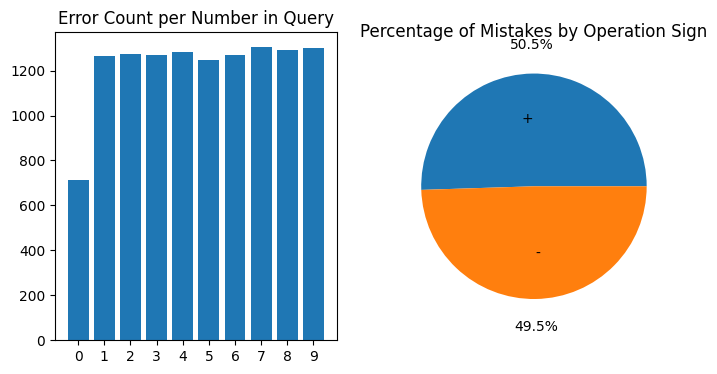

In [234]:
img_gen = t2i_model_extra.predict(X_test_txt)
preds = discrim_model.predict(img_gen)
for i in range(preds.shape[0]):
    for t in range(3):
        pred = np.argmax(preds[i,t,:])
        preds[i,t,:] *= 0
        preds[i,t,pred] = 1

error_counter, error_in = plotter_1(X_test_txt, y_test_txt, preds)

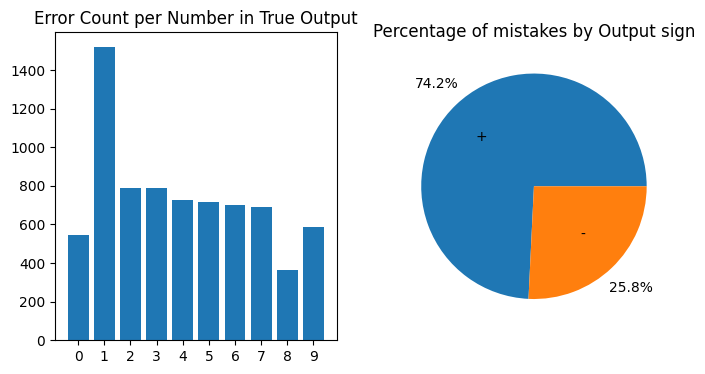

In [235]:
_, error_out = plotter_2(y_test_txt, preds)

In [236]:
print(error_counter)
print(error_in)
print(error_out)

3710
[ 714 1266 1272 1268 1284 1248 1268 1305 1293 1302 1874 1836  718]
[ 544 1520  790  789  727  715  702  692  362  588    0  956 2012]


In [237]:
print(mean_absolute_error(y_test_txt, preds))

18.8425


In [238]:
print(1-(error_counter / y_test_txt.shape[0]))

0.07250000000000001
